<a href="https://colab.research.google.com/github/nblashintaa/PBA-Brimo-SentimentAnalysis/blob/main/NAMA_NOTEBOOK.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week3-Scrapping Apps Review BRImo
### Nabila Shinta Luthfia
### 5026231038

In [3]:
#Install library yang digunakan untuk scraping Google Play Store
!pip install google_play_scraper
!pip install textblob

#Import library yang digunakan
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [4]:
# Mengambil data review terbaru dari aplikasi BRImo di Google Play Store
# Menggunakan library google_play_scraper

from google_play_scraper import app, Sort, reviews_all

brimo_reviews = reviews_all(
    'id.co.bri.brimo',
    sleep_milliseconds=0,
    lang='id', # mengambil review bahasa Indonesia
    sort=Sort.NEWEST, # mengambil review terbaru
)

In [5]:
# Data hasil scraping diubah menjadi pandas dataframe. Kemudian disimpan dalam file CSV untuk analisis selanjutnya
# Mengubah data hasil scraping menjadi pandas dataframe dengan nama variabel yang relevan
df_brimo = pd.DataFrame(np.array(brimo_reviews), columns=['content'])
df_brimo = df_brimo.join(pd.DataFrame(df_brimo.pop('content').tolist()))
df_brimo.to_csv("brimo_raw_reviews.csv", index=False)
# Menampilkan 5 data teratas
df_brimo.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,daedabb3-8d37-4587-9e52-0a89c025b41d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot susah trnfen juga.. tolong di perbaiki j...,5,0,2.92.1,2026-03-15 13:11:42,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-11-01 10:02:25,2.92.1
1,720f9a74-1b57-4e8d-8fc1-b47710e5b165,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa masuk kocak,5,0,2.95.0,2026-03-15 13:11:38,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-03-15 14:27:14,2.95.0
2,4c7158b6-8729-49e1-aa0b-22b96060ad4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mempermudah transaksi,5,0,2.94.0,2026-03-15 13:10:04,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:26:36,2.94.0
3,ff662000-6c8d-4ab9-9839-bfe68c079787,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0,2.94.0,2026-03-15 13:08:50,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:22:40,2.94.0
4,bd67718b-e62b-47ce-8385-8a40046e1dad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus dan sangat bermanfaat,5,0,2.94.0,2026-03-15 13:08:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:27:05,2.94.0


In [6]:
df_brimo

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,daedabb3-8d37-4587-9e52-0a89c025b41d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot susah trnfen juga.. tolong di perbaiki j...,5,0,2.92.1,2026-03-15 13:11:42,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-11-01 10:02:25,2.92.1
1,720f9a74-1b57-4e8d-8fc1-b47710e5b165,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa masuk kocak,5,0,2.95.0,2026-03-15 13:11:38,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-03-15 14:27:14,2.95.0
2,4c7158b6-8729-49e1-aa0b-22b96060ad4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mempermudah transaksi,5,0,2.94.0,2026-03-15 13:10:04,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:26:36,2.94.0
3,ff662000-6c8d-4ab9-9839-bfe68c079787,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0,2.94.0,2026-03-15 13:08:50,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:22:40,2.94.0
4,bd67718b-e62b-47ce-8385-8a40046e1dad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus dan sangat bermanfaat,5,0,2.94.0,2026-03-15 13:08:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:27:05,2.94.0
...,...,...,...,...,...,...,...,...,...,...,...
858971,0a2174b1-890f-4fea-8317-4cb783d02066,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jozz,5,1,1.3.0,2019-02-26 05:49:31,None,NaT,1.3.0
858972,d93d6edf-3844-4420-abd7-166691b1f791,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semakin canggih aplikasi BRI dan dipermudah lagi,5,2,None,2019-02-26 05:43:51,None,NaT,None
858973,042cc988-7ef1-4ba2-a574-05d35372b2fb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantapsss,5,0,1.3.0,2019-02-26 05:38:54,None,NaT,1.3.0
858974,97f21f6d-6e84-446e-8573-b0820ac777aa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gooooooood,5,1,1.3.0,2019-02-26 05:31:38,None,NaT,1.3.0


In [7]:
df_brimo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858976 entries, 0 to 858975
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              858976 non-null  object        
 1   userName              858976 non-null  object        
 2   userImage             858976 non-null  object        
 3   content               858976 non-null  object        
 4   score                 858976 non-null  int64         
 5   thumbsUpCount         858976 non-null  int64         
 6   reviewCreatedVersion  723284 non-null  object        
 7   at                    858976 non-null  datetime64[ns]
 8   replyContent          853647 non-null  object        
 9   repliedAt             853647 non-null  datetime64[ns]
 10  appVersion            723284 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 72.1+ MB


In [8]:
df_analysis = df_brimo.loc[:, ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,lemot susah trnfen juga.. tolong di perbaiki j...,5,0,2.92.1,2026-03-15 13:11:42,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-11-01 10:02:25
1,ga bisa masuk kocak,5,0,2.95.0,2026-03-15 13:11:38,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-03-15 14:27:14
2,mempermudah transaksi,5,0,2.94.0,2026-03-15 13:10:04,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:26:36
3,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0,2.94.0,2026-03-15 13:08:50,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:22:40
4,bagus dan sangat bermanfaat,5,0,2.94.0,2026-03-15 13:08:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:27:05


In [9]:
df_brimo['score'].value_counts()

,count
score,
5,614430
1,135485
4,51439
2,28942
3,28680


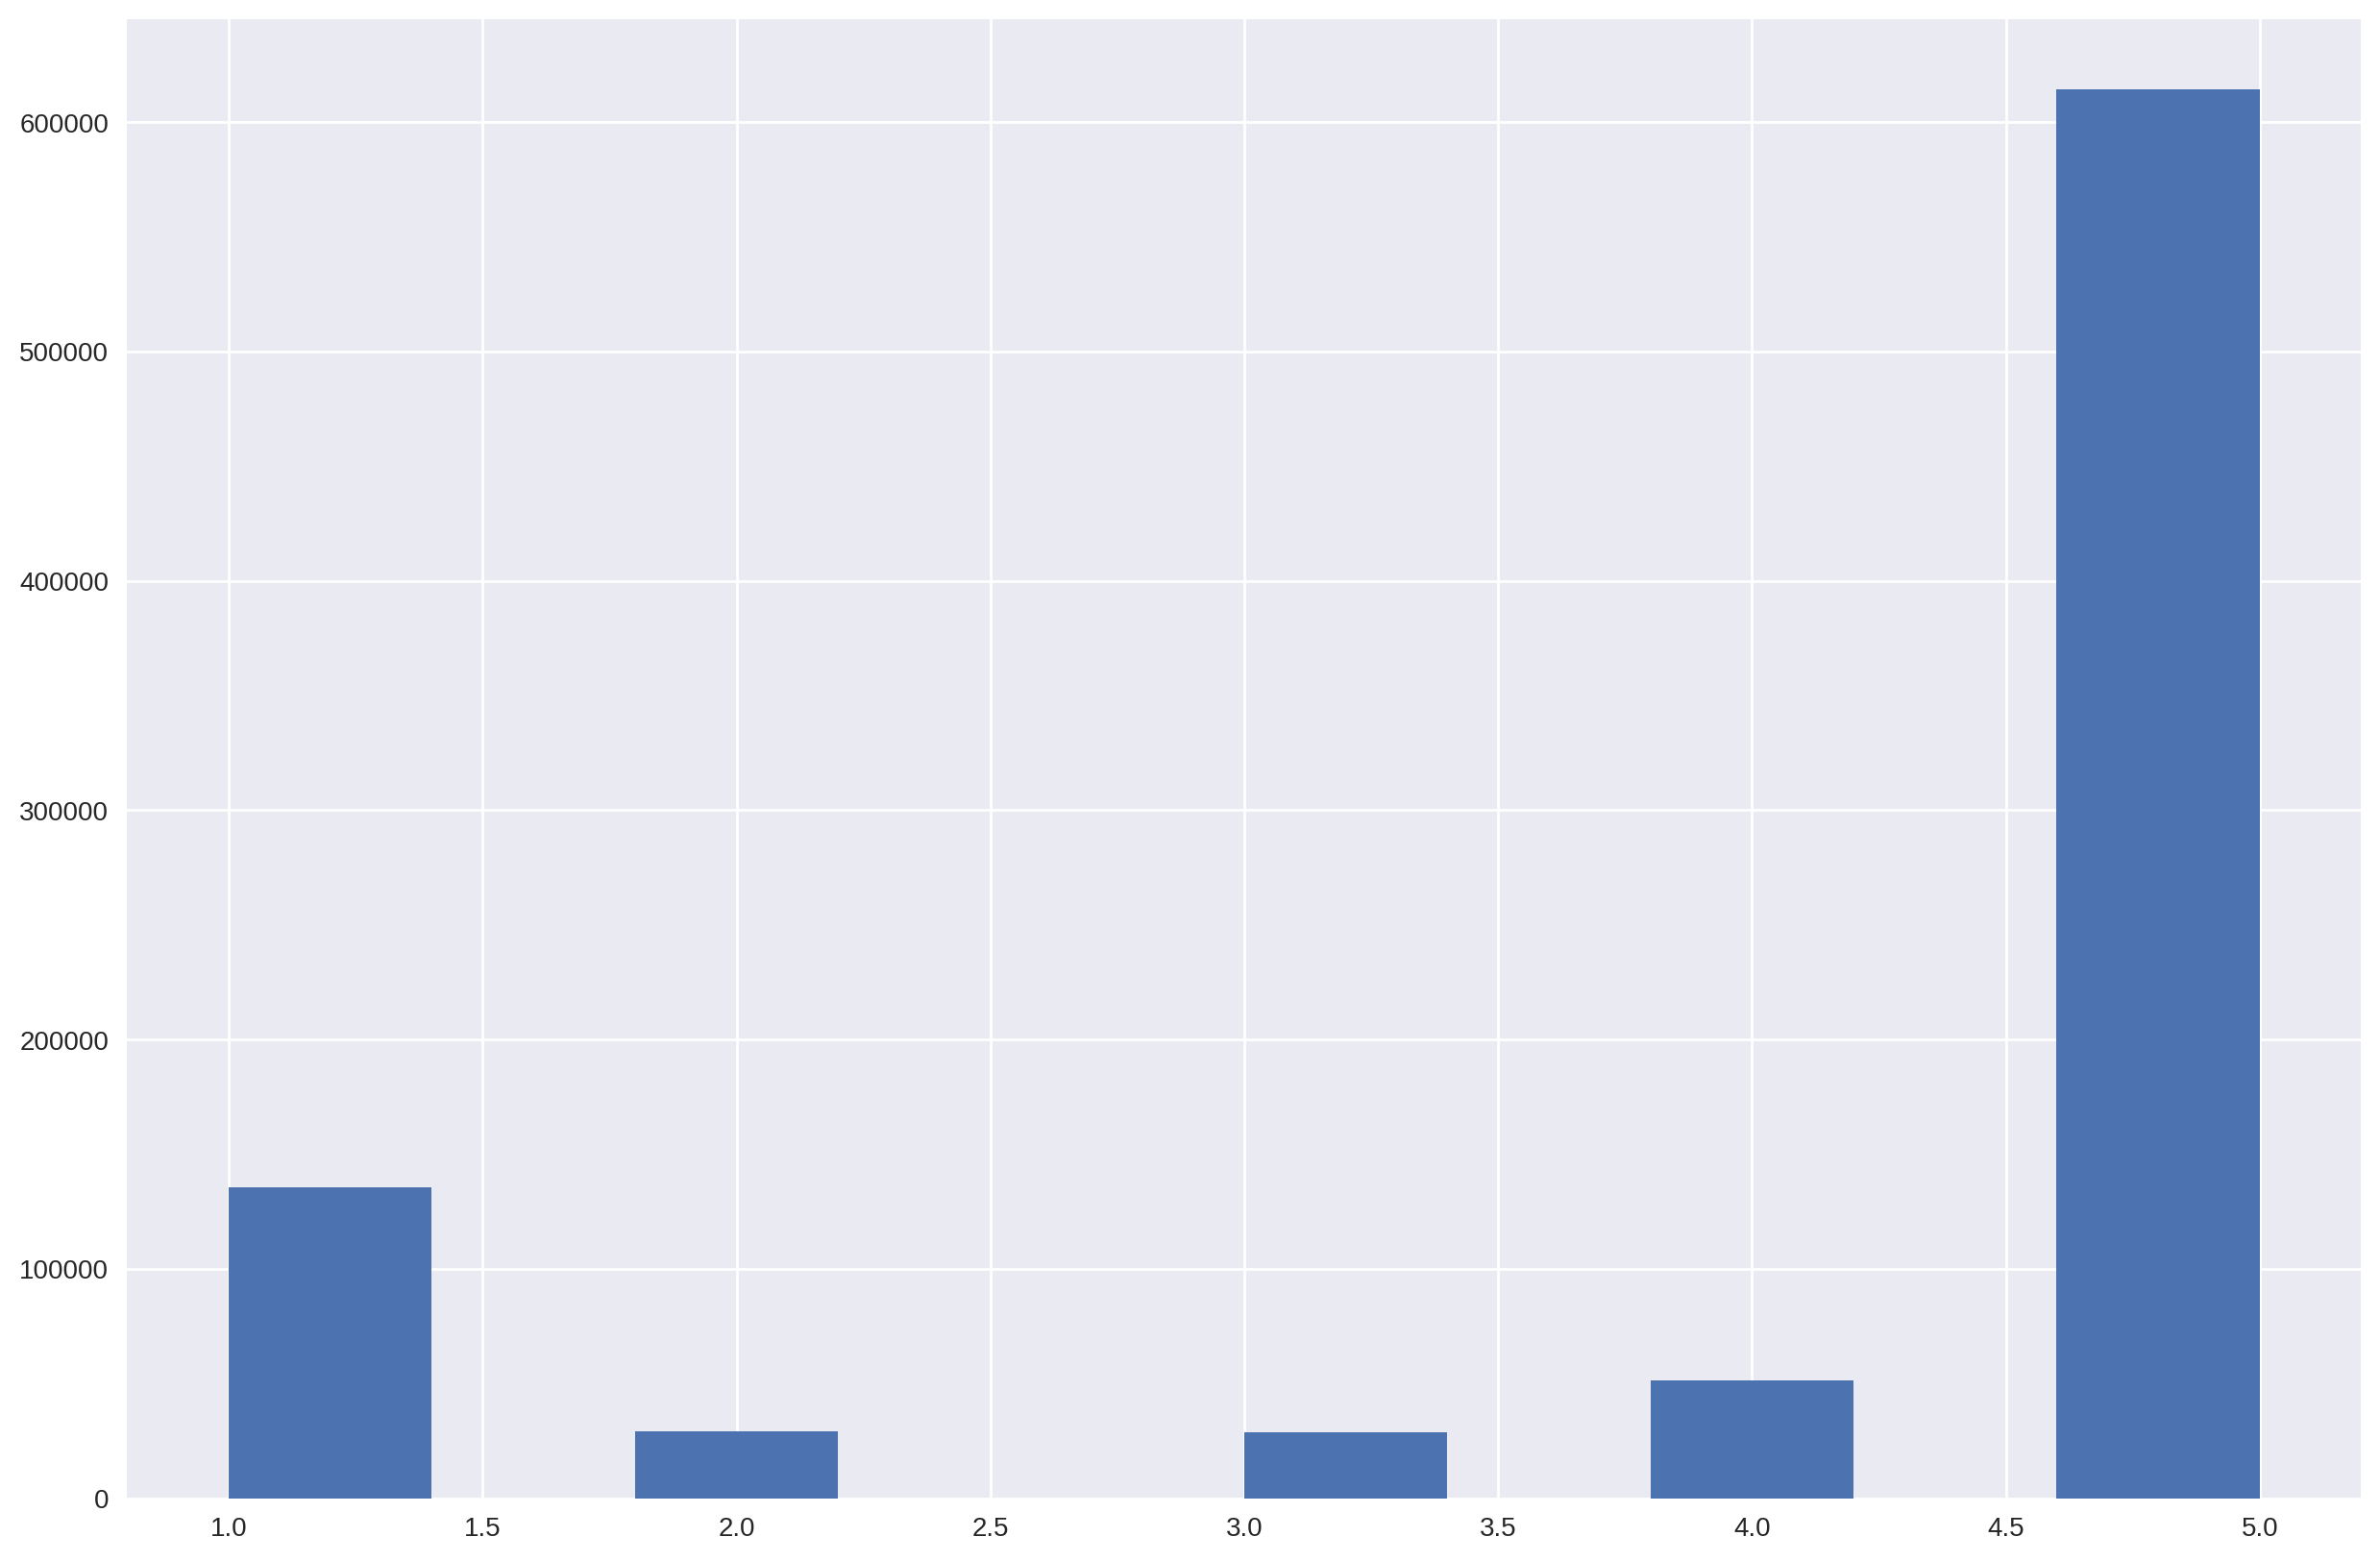

In [10]:
plt.hist(df_brimo['score'])
plt.show()

In [11]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.6 MB/s eta 0:00:00


In [16]:
# Analisis sentimen review menggunakan TextBlob
# Polarity  : skor positif/negatif (-1 s.d 1)
# Subjectivity : tingkat subjektif/objektif (0 s.d 1)
# astype(str) dipakai untuk menghindari error jika ada nilai kosong

from textblob import TextBlob

df_brimo['sentiment_polarity'] = df_brimo['content'].astype(str).apply(
    lambda x: TextBlob(x).polarity
)

df_brimo['sentiment_subjective'] = df_brimo['content'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity
)

In [17]:
# Menampilkan kolom penting: isi review, rating, dan hasil analisis sentimen
# Untuk melihat hubungan antara teks ulasan dan skor sentimennya
df_brimo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,lemot susah trnfen juga.. tolong di perbaiki jaringan aplikasinya.. jangan bikin saya emosi nugu jaringan kurang baik.. aplikasi yang lain bagus tidak ada kendala.,5,0.00,0.00
1,ga bisa masuk kocak,5,0.00,0.00
2,mempermudah transaksi,5,0.00,0.00
3,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0.35,0.55
4,bagus dan sangat bermanfaat,5,0.00,0.00
...,...,...,...,...
858971,jozz,5,0.00,0.00
858972,semakin canggih aplikasi BRI dan dipermudah lagi,5,0.00,0.00
858973,mantapsss,5,0.00,0.00
858974,gooooooood,5,0.00,0.00


In [18]:
# DATA PREPROCESSING — LOWER CASING

# Mengubah tipe data kolom 'content' menjadi string
# Hal ini penting karena ada kemungkinan data berisi NaN / None / tipe lain
# yang bisa menyebabkan error saat pemrosesan teks
df_brimo['content'] = df_brimo['content'].astype(str)

# Menampilkan beberapa contoh review sebelum proses lowercasing
# Tujuannya untuk melihat kondisi teks asli (masih ada huruf besar/kecil campur)
print(df_brimo['content'][188])
print(df_brimo['content'][1])
print(df_brimo['content'][20100])

terbaik
ga bisa masuk kocak
knp ya ko sekarang gak bs up date brimoq ya ap memang ganguan


In [19]:
# Mengubah seluruh huruf pada teks review menjadi huruf kecil
# Tujuannya untuk menyeragamkan format teks agar konsisten
# Contoh: "Bagus" dan "bagus" akan dianggap kata yang sama dalam NLP
df_brimo['content']= df_brimo['content'].apply(lambda x: x.lower())

# Menampilkan beberapa contoh review setelah proses lowercasing
# Untuk membandingkan dengan kondisi sebelum lowercasing
print(df_brimo['content'][188])
print(df_brimo['content'][1])
print(df_brimo['content'][20100])

terbaik
ga bisa masuk kocak
knp ya ko sekarang gak bs up date brimoq ya ap memang ganguan


Stopwords Removal

Indonesian Stopwords

In [20]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Mengambil daftar stopwords Bahasa Indonesia dari NLTK
# Stopwords = kata umum yang sering muncul tapi tidak punya makna penting
# Contoh: "dan", "yang", "di", "ke", "dari", dll
indonesian_stopwords = stopwords.words('indonesian')

# Menampilkan 20 stopwords pertama sebagai contoh
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [23]:
# Feature Extraction - Counting Text Attributes
import string

# 1) wordCount
# Menghitung jumlah kata dalam setiap review.
# Membantu mengetahui seberapa panjang atau pendek sebuah ulasan.
df_brimo['wordCount'] = [len(review.split()) for review in df_brimo['content']]

# 2) uppercaseCharCount
# Menghitung jumlah karakter huruf kapital dalam setiap review.
df_brimo['uppercaseCharCount'] = [
    sum(char.isupper() for char in review) for review in df_brimo['content']
]

# 3) specialCharCount
# Menghitung jumlah karakter khusus (tanda baca / simbol) pada setiap review.
df_brimo['specialCharCount'] = [
    sum(char in string.punctuation for char in review) for review in df_brimo['content']
]




In [24]:
# Menampilkan kolom-kolom penting dari dataset review
df_brimo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,lemot susah trnfen juga.. tolong di perbaiki jaringan aplikasinya.. jangan bikin saya emosi nugu jaringan kurang baik.. aplikasi yang lain bagus tidak ada kendala.,5,0.00,0.00,24,0,7
1,ga bisa masuk kocak,5,0.00,0.00,4,0,0
2,mempermudah transaksi,5,0.00,0.00,2,0,0
3,saya kasi bintang full ya mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0.35,0.55,7,0,0
4,bagus dan sangat bermanfaat,5,0.00,0.00,4,0,0
...,...,...,...,...,...,...,...
858971,jozz,5,0.00,0.00,1,0,0
858972,semakin canggih aplikasi bri dan dipermudah lagi,5,0.00,0.00,7,0,0
858973,mantapsss,5,0.00,0.00,1,0,0
858974,gooooooood,5,0.00,0.00,1,0,0


In [25]:
# Menambahkan kolom baru bernama 'sentiment_rating'
# Kolom ini berisi label sentimen berdasarkan rating bintang dari pengguna
df_brimo['sentiment_rating'] = df_brimo['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [28]:
# Menampilkan kolom-kolom penting untuk analisis sentimen
df_brimo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,lemot susah trnfen juga.. tolong di perbaiki jaringan aplikasinya.. jangan bikin saya emosi nugu jaringan kurang baik.. aplikasi yang lain bagus tidak ada kendala.,5,0.00,0.00,Positive
1,ga bisa masuk kocak,5,0.00,0.00,Positive
2,mempermudah transaksi,5,0.00,0.00,Positive
3,saya kasi bintang full ya mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0.35,0.55,Positive
4,bagus dan sangat bermanfaat,5,0.00,0.00,Positive
...,...,...,...,...,...
858971,jozz,5,0.00,0.00,Positive
858972,semakin canggih aplikasi bri dan dipermudah lagi,5,0.00,0.00,Positive
858973,mantapsss,5,0.00,0.00,Positive
858974,gooooooood,5,0.00,0.00,Positive


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


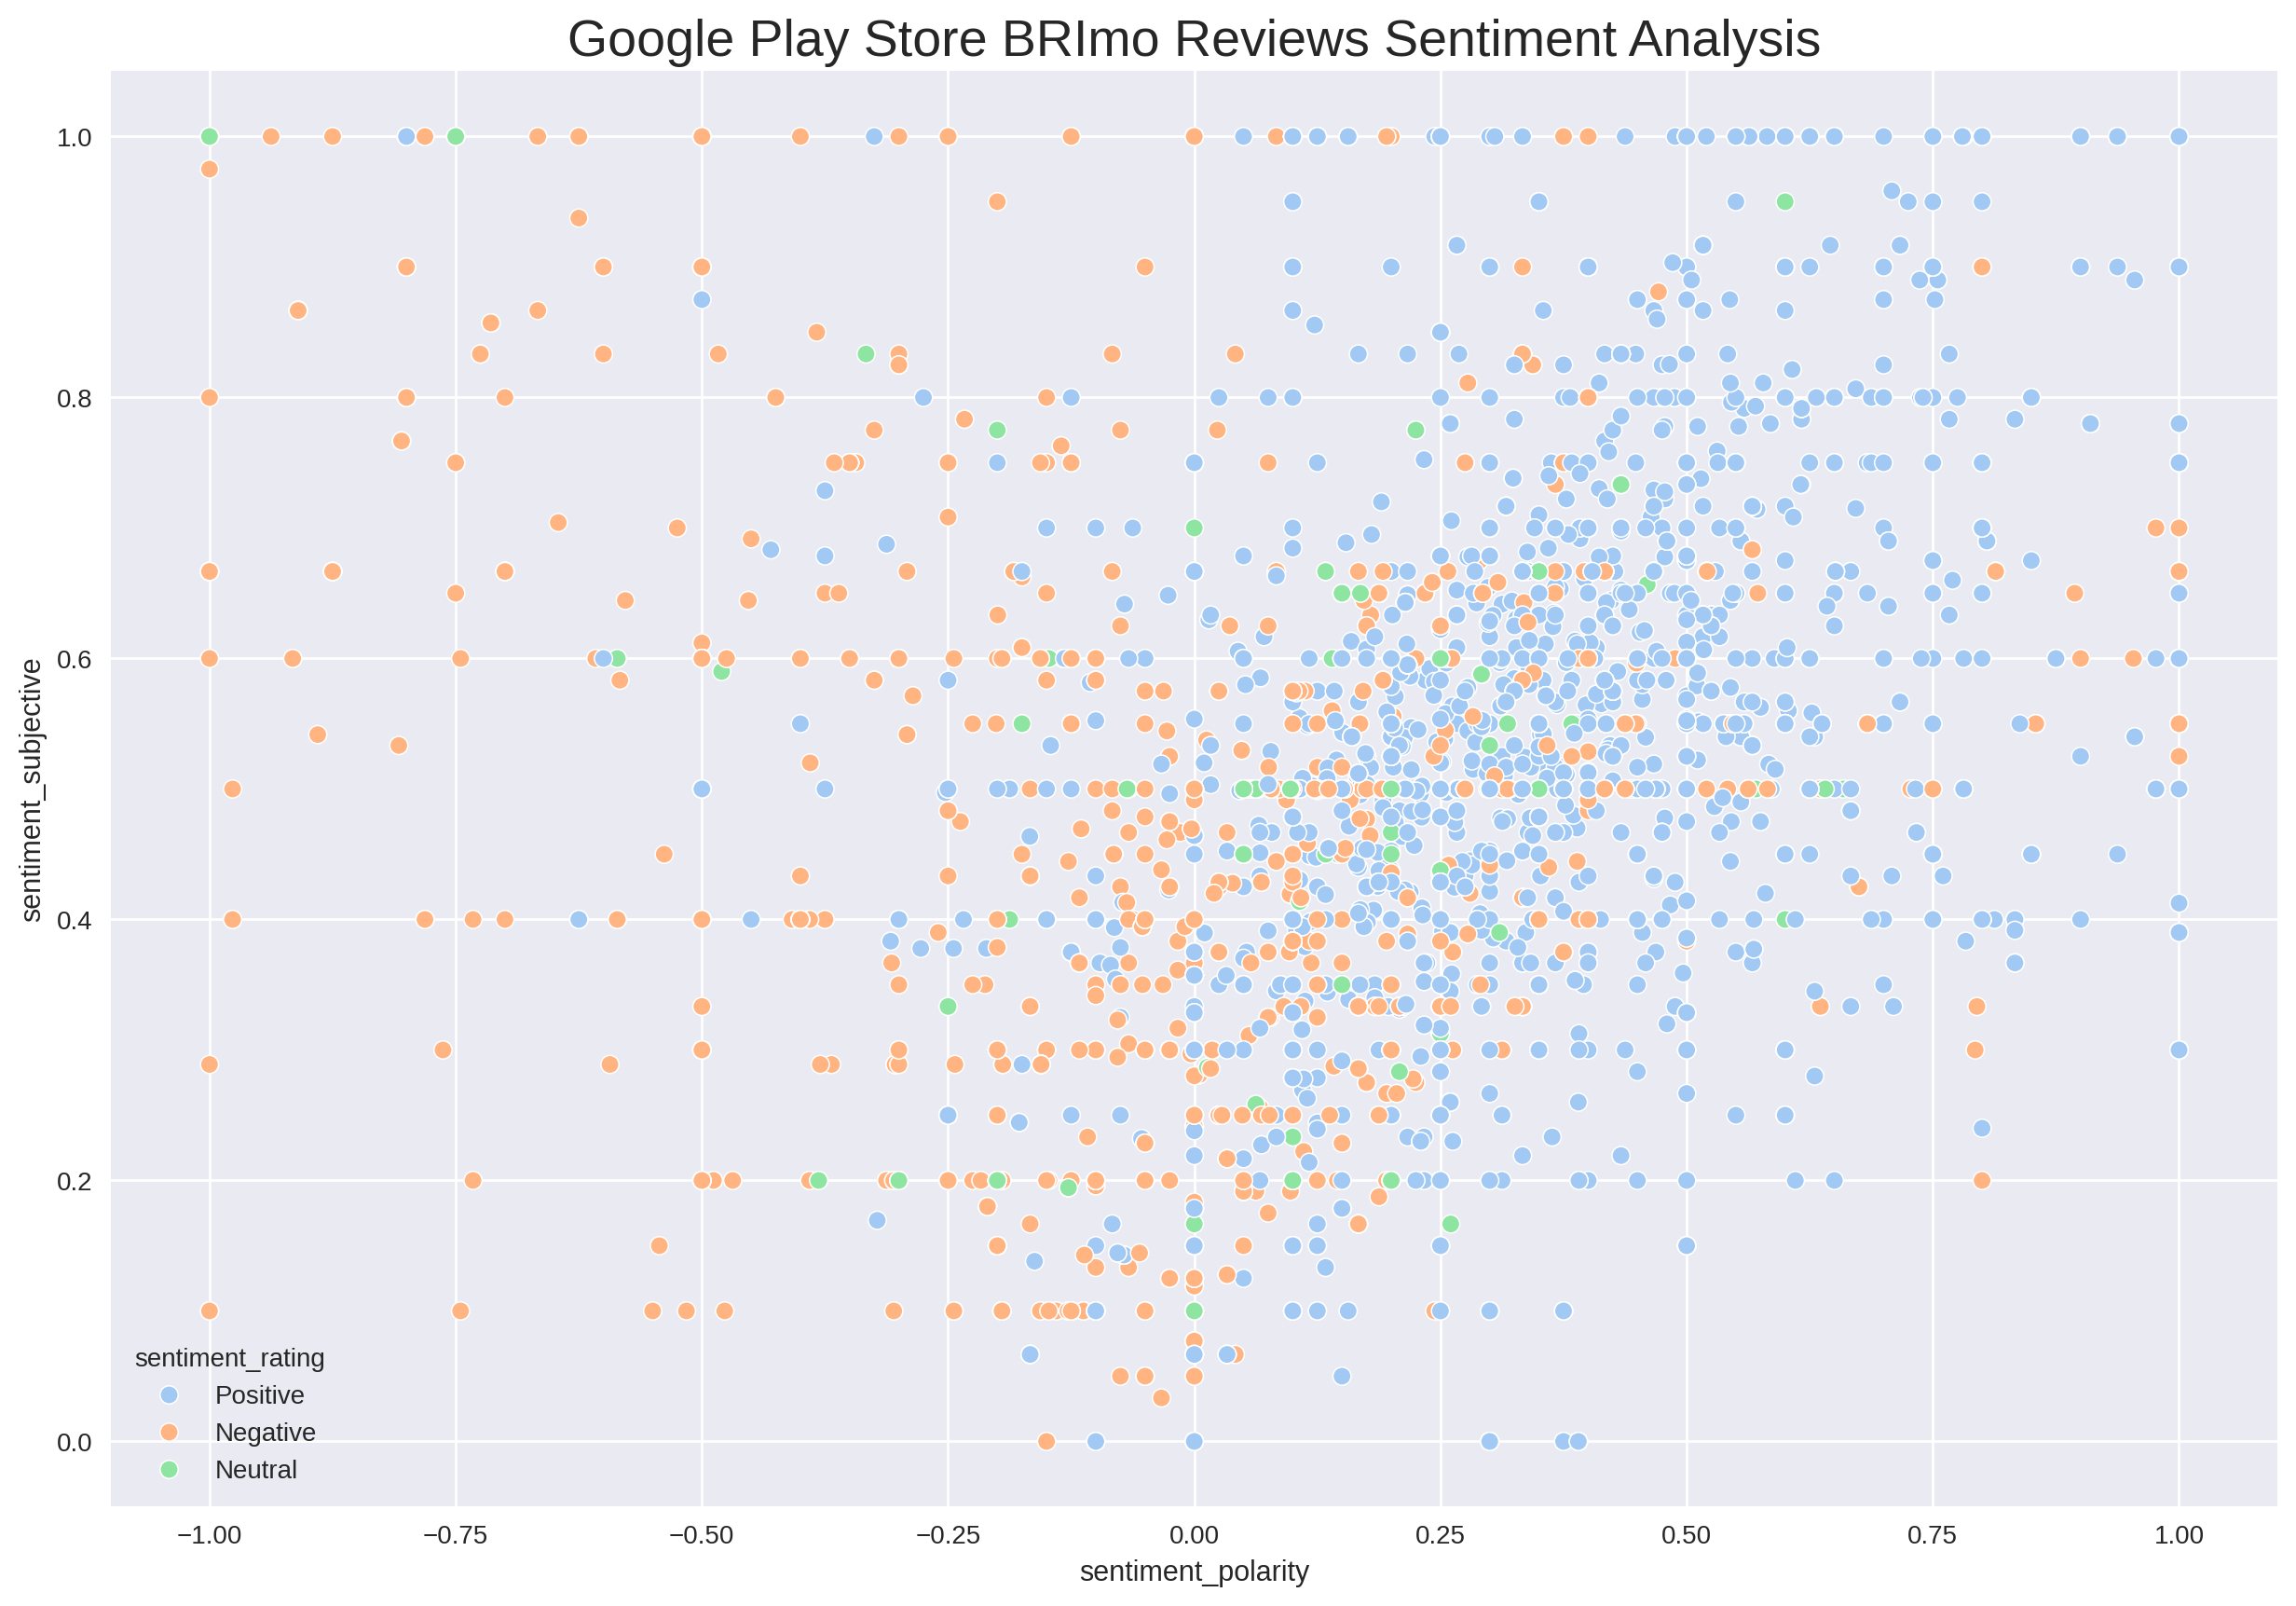

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat kanvas grafik dengan ukuran besar agar titik data terlihat jelas
plt.figure(figsize=(15, 10))

# Membuat scatter plot untuk melihat persebaran sentimen review
sns.scatterplot(
    x=df_brimo['sentiment_polarity'],      # Sumbu X = polaritas sentimen (-1 s.d 1)
    y=df_brimo['sentiment_subjective'],   # Sumbu Y = subjektivitas (0 s.d 1)
    hue=df_brimo['sentiment_rating'],     # Warna titik berdasarkan label sentimen
    edgecolor='white',                     # Garis tepi titik agar lebih jelas
    palette="pastel"                       # Skema warna lembut
)

# Judul grafik
plt.title("Google Play Store BRImo Reviews Sentiment Analysis", fontsize=20)

# Menampilkan grafik
plt.show()

In [30]:
# Function untuk menampilkan kata-kata yang paling sering muncul pada kumpulan teks
def freq_words(x, terms = 30):
  # Menggabungkan seluruh teks review menjadi satu string besar
  all_words = ' '.join([text for text in x])

  # Memecah string menjadi daftar kata
  all_words = all_words.split()

  # Import FreqDist untuk menghitung frekuensi kemunculan kata
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)

  # Mengubah hasil frekuensi menjadi DataFrame
  words_df = pd.DataFrame({
      'word': list(fdist.keys()),      # daftar kata unik
      'count': list(fdist.values())    # jumlah kemunculan tiap kata
  })

  # Mengambil N kata dengan frekuensi tertinggi (default 30 kata)
  d = words_df.nlargest(columns="count", n=terms)

  # Membuat grafik batang
  plt.figure(figsize=(20,5))
  ax = sns.barplot(
      data=d,
      x="word",        # sumbu X = kata
      y="count",       # sumbu Y = jumlah kemunculan
      palette="rainbow"
  )
  ax.set(ylabel='Count')
  plt.show()

/tmp/ipykernel_299/4006536983.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


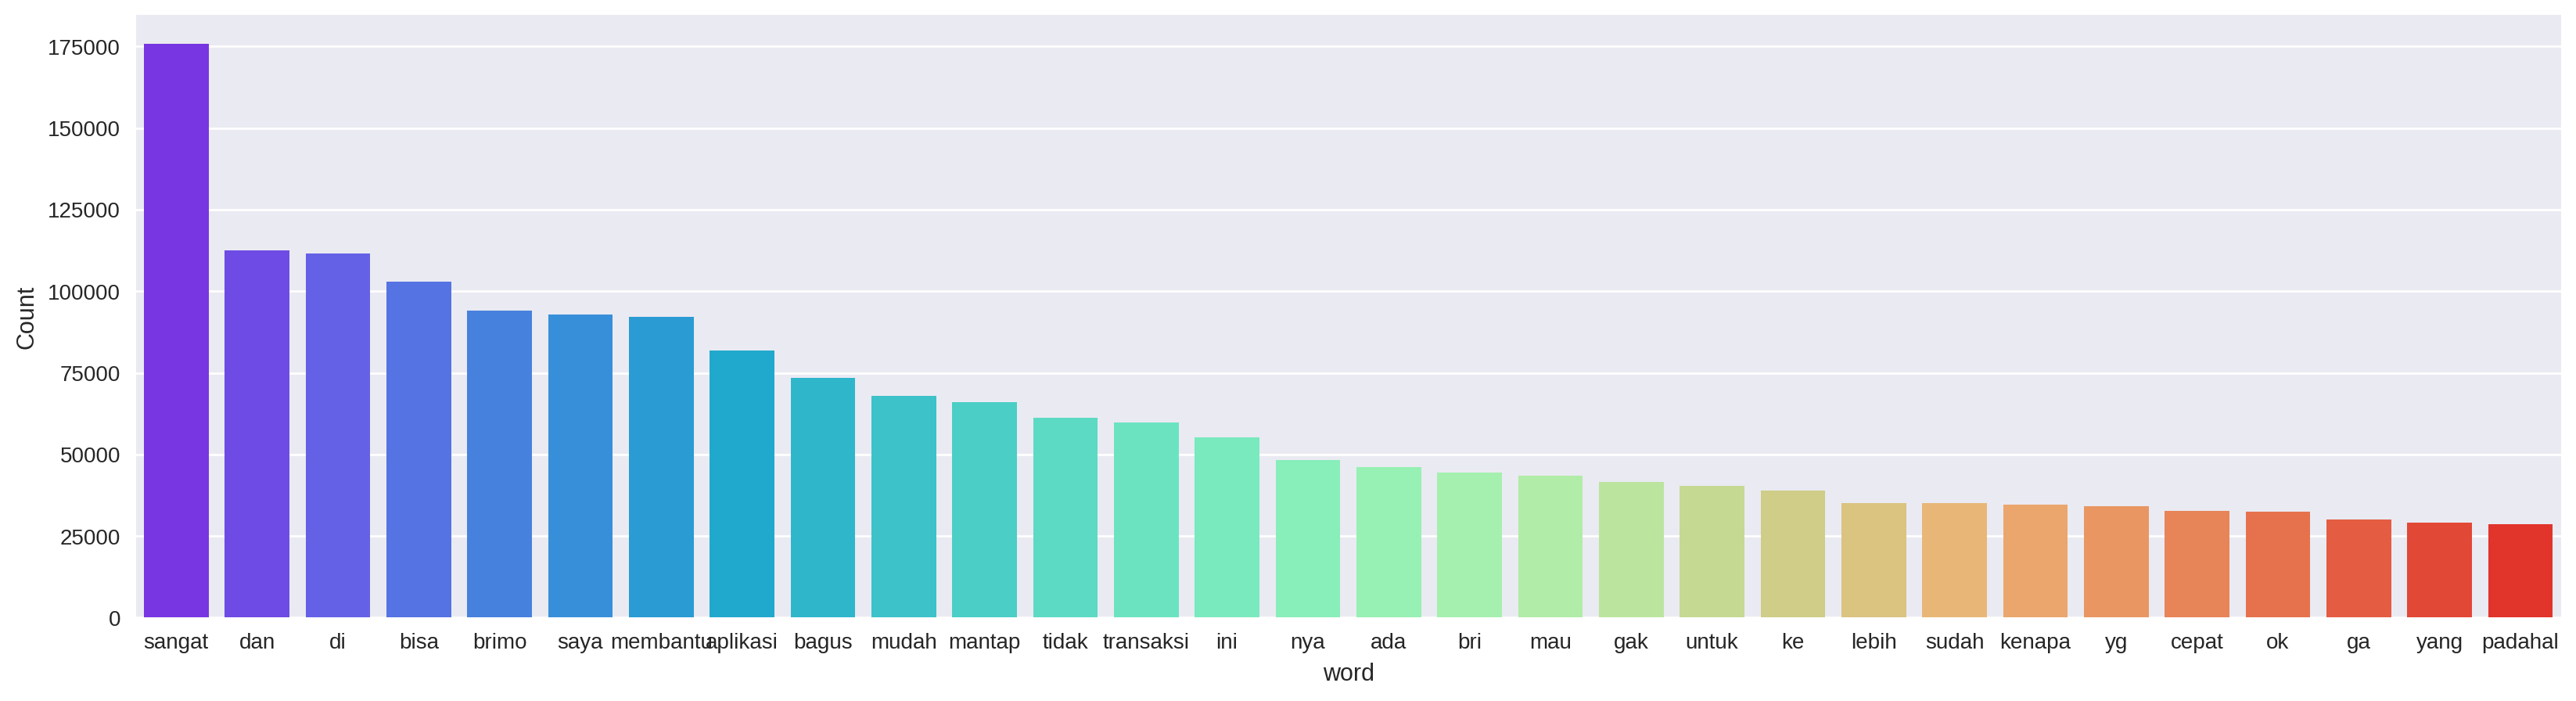

In [31]:
freq_words(df_brimo['content'])

In [32]:
# Proses ini digunakan untuk menghapus stopwords Bahasa Indonesia

# Install library Sastrawi (library NLP Bahasa Indonesia)
!pip install Sastrawi

# Import StopWordRemoverFactory untuk membuat penghapus stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Membuat objek factory untuk mengakses daftar stopwords Bahasa Indonesia
factory = StopWordRemoverFactory()

# Membuat stopword remover berdasarkan daftar stopwords bawaan Sastrawi
stopword_remover = factory.create_stop_word_remover()

# Menerapkan penghapusan stopwords pada setiap teks review di kolom 'content'
# Menggunakan apply() agar setiap baris diproses satu per satu
df_brimo['content'] = df_brimo['content'].apply(lambda x: stopword_remover.remove(x))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.3 MB/s eta 0:00:00


In [33]:
# Menambahkan pembersihan stopwords Bahasa Inggris

# Download daftar stopwords dari NLTK
import nltk
nltk.download('stopwords')

# Import stopwords corpus
from nltk.corpus import stopwords

# Mengambil daftar stopwords Bahasa Inggris
english_stopwords = stopwords.words('english')

# Menghapus stopwords Inggris dari setiap teks review pada kolom 'content'
# Split() : memecah kalimat jadi kata
df_brimo['content'] = df_brimo['content'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in english_stopwords])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
len(english_stopwords)

198

In [36]:
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [37]:
df_brimo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,lemot susah trnfen juga.. di perbaiki jaringan aplikasinya.. jangan bikin emosi nugu jaringan kurang baik.. aplikasi lain bagus ada kendala.,5,0.00,0.00,Positive
1,ga masuk kocak,5,0.00,0.00,Positive
2,mempermudah transaksi,5,0.00,0.00,Positive
3,kasi bintang full mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0.35,0.55,Positive
4,bagus sangat bermanfaat,5,0.00,0.00,Positive
...,...,...,...,...,...
858971,jozz,5,0.00,0.00,Positive
858972,semakin canggih aplikasi bri dipermudah,5,0.00,0.00,Positive
858973,mantapsss,5,0.00,0.00,Positive
858974,gooooooood,5,0.00,0.00,Positive


In [38]:
# function untuk menampilkan kata-kata yang paling sering muncul
def freq_words(x, terms = 30):

  # Menggabungkan semua teks dalam kolom menjadi satu string panjang
  all_words = ' '.join([text for text in x])

  # Memecah string menjadi list kata
  all_words = all_words.split()

  # Import FreqDist untuk menghitung frekuensi kata
  from nltk.probability import FreqDist

  # Menghitung jumlah kemunculan setiap kata
  fdist = FreqDist(all_words)

  # Mengubah hasil frekuensi ke dalam bentuk DataFrame
  words_df = pd.DataFrame({
      'word': list(fdist.keys()),      # daftar kata unik
      'count': list(fdist.values())    # jumlah kemunculan tiap kata
  })

  # Mengambil N kata dengan frekuensi tertinggi
  d = words_df.nlargest(columns="count", n = terms)

  # Mengatur ukuran gambar
  plt.figure(figsize=(20,5))

  # Membuat bar chart frekuensi kata
  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")

  # Memberi label sumbu Y
  ax.set(ylabel='Count')

  # Menampilkan grafik
  plt.show()

/tmp/ipykernel_299/106516156.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


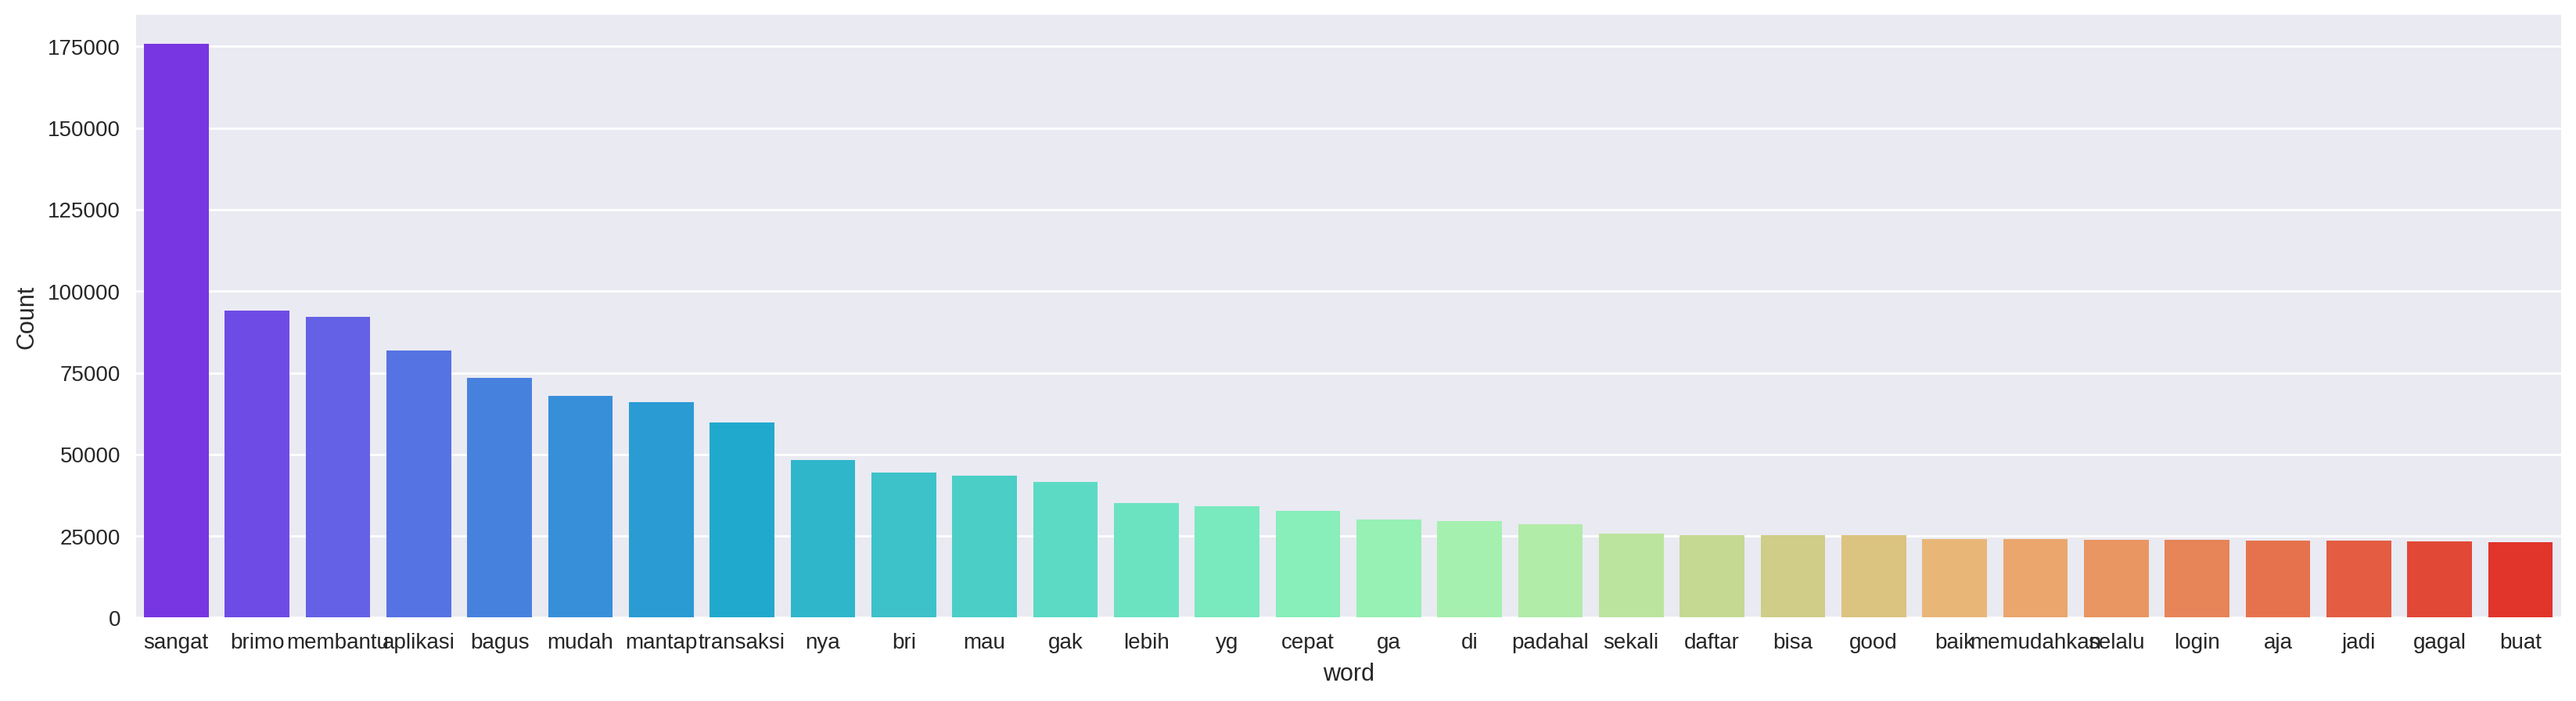

In [39]:
freq_words(df_brimo['content'])

In [44]:
# Menghitung jumlah kata sebelum dan sesudah stopwords removal
import string

df_brimo_stopwords = df_brimo.copy()

if 'review_after_stopwords' not in df_brimo_stopwords.columns:
    df_brimo_stopwords['review_after_stopwords'] = ''

df_brimo_stopwords['review_after_stopwords'] = df_brimo_stopwords['review_after_stopwords'].fillna('')

df_brimo_stopwords['wordCount'] = [
    len(str(review).split())
    for review in df_brimo_stopwords['content']
]

df_brimo_stopwords['wordCount_after_stopwords'] = [
    len(str(review).split())
    for review in df_brimo_stopwords['review_after_stopwords']
]

df_brimo_stopwords[['content','review_after_stopwords','wordCount','wordCount_after_stopwords']].head()

,content,review_after_stopwords,wordCount,wordCount_after_stopwords
0,lemot susah trnfen juga.. di perbaiki jaringan aplikasinya.. jangan bikin emosi nugu jaringan kurang baik.. aplikasi lain bagus ada kendala.,,20,0
1,ga masuk kocak,,3,0
2,mempermudah transaksi,,2,0
3,kasi bintang full mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,,5,0
4,bagus sangat bermanfaat,,3,0
